In [1]:
using Pkg 
Pkg.activate("../.")
include("../src/model.jl")
include("../src/analysis.jl")
include("../src/plotting.jl")

coverage_1 = coverage_levels("RA_short")
coverage_2 = coverage_levels("RA_intermidiate";smax = 2.5)
coverage_3 = coverage_levels("RA_long";smax = 2.5)

plot_policy(coverage_1,coverage_2,coverage_3,"smax")

  Activating project at `~/github/FisheriesInsuranceModel`
Precompiling ValueFunctionIterations
  ✓ Static
  ✓ StaticArrays → StaticArraysChainRulesCoreExt
  ✓ Adapt → AdaptStaticArraysExt
  ✓ SpecialFunctions → SpecialFunctionsChainRulesCoreExt
  ✓ StaticArrayInterface
  ✓ Interpolations
  ✓ StaticArrayInterface → StaticArrayInterfaceOffsetArraysExt
  ✓ StaticArrayInterface → StaticArrayInterfaceStaticArraysExt
  ✓ ComponentArrays
  ✓ Interpolations → InterpolationsUnitfulExt
  ✓ JLD2
  ✓ ValueFunctionIterations
  12 dependencies successfully precompiled in 42 seconds. 90 already precompiled.
Precompiling StatsFunsChainRulesCoreExt
  ✓ StatsFuns → StatsFunsInverseFunctionsExt
  ✓ StatsFuns → StatsFunsChainRulesCoreExt
  2 dependencies successfully precompiled in 5 seconds. 22 already precompiled.
Precompiling DistributionsChainRulesCoreExt
  ✓ Distributions → DistributionsChainRulesCoreExt
  1 dependency successfully precompiled in 2 seconds. 45 already precompiled.
Precompiling Speci

LoadError: SystemError: opening file "results/RA_short/sol.jld2": No such file or directory

  Activating project at `~/github/FisheriesInsuranceModel`
  Activating project at `~/github/FisheriesInsuranceModel`


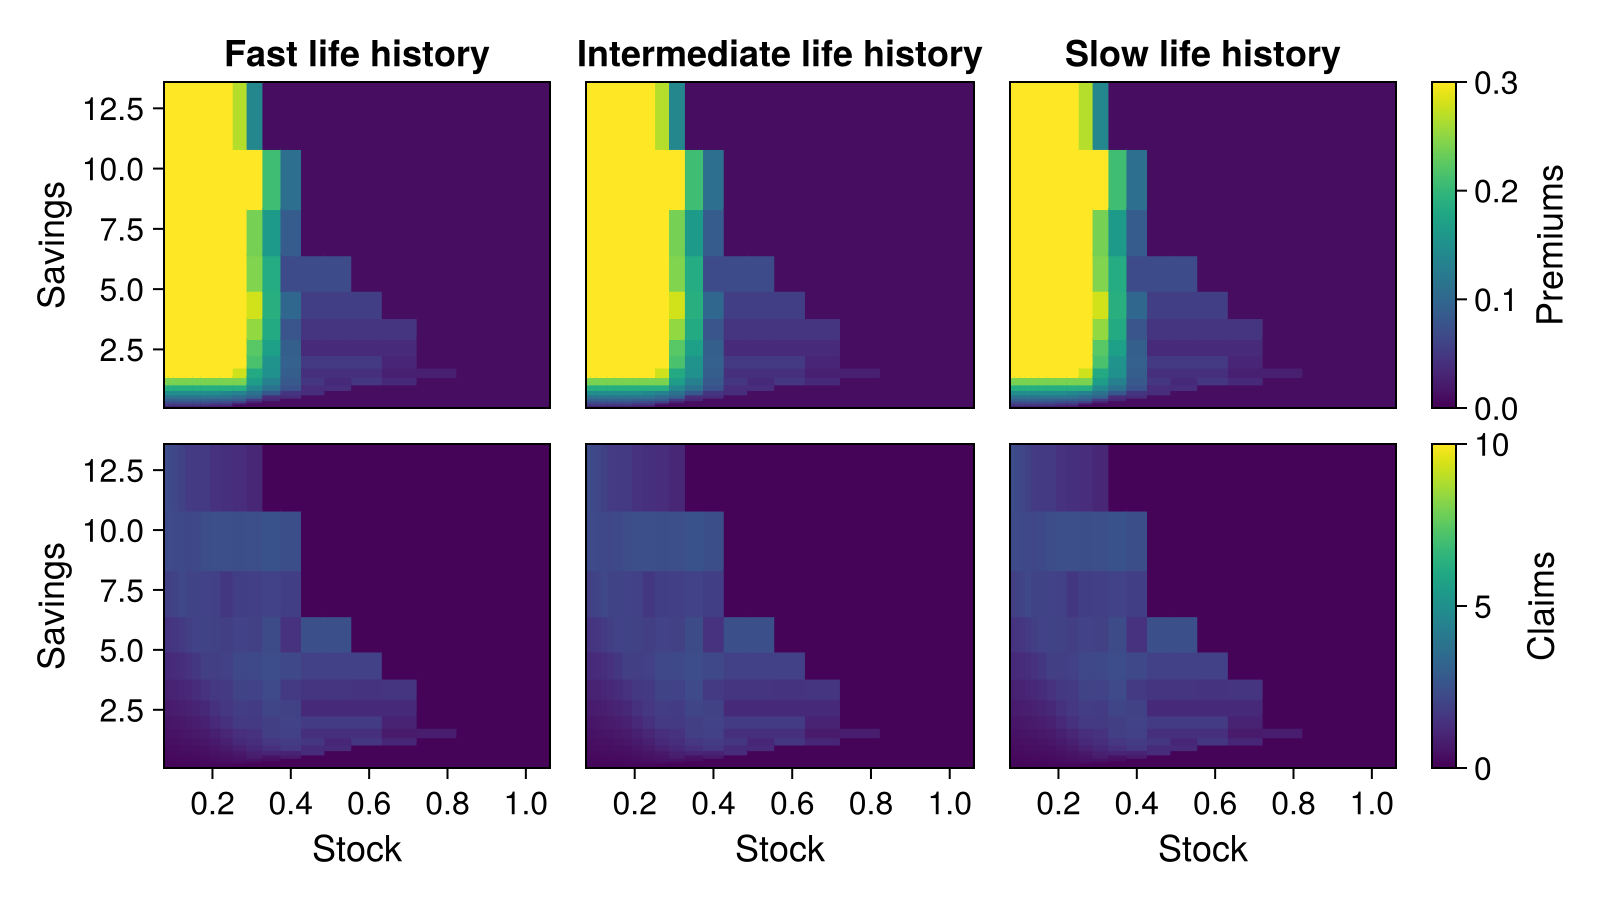

In [2]:
using Pkg 
include("../src/model.jl")
include("../src/analysis.jl")
include("../src/plotting.jl")
coverage_1 = coverage_levels("RA_short";smax = 2.5)
plot_policy(coverage_1,coverage_1,coverage_1,"smax")

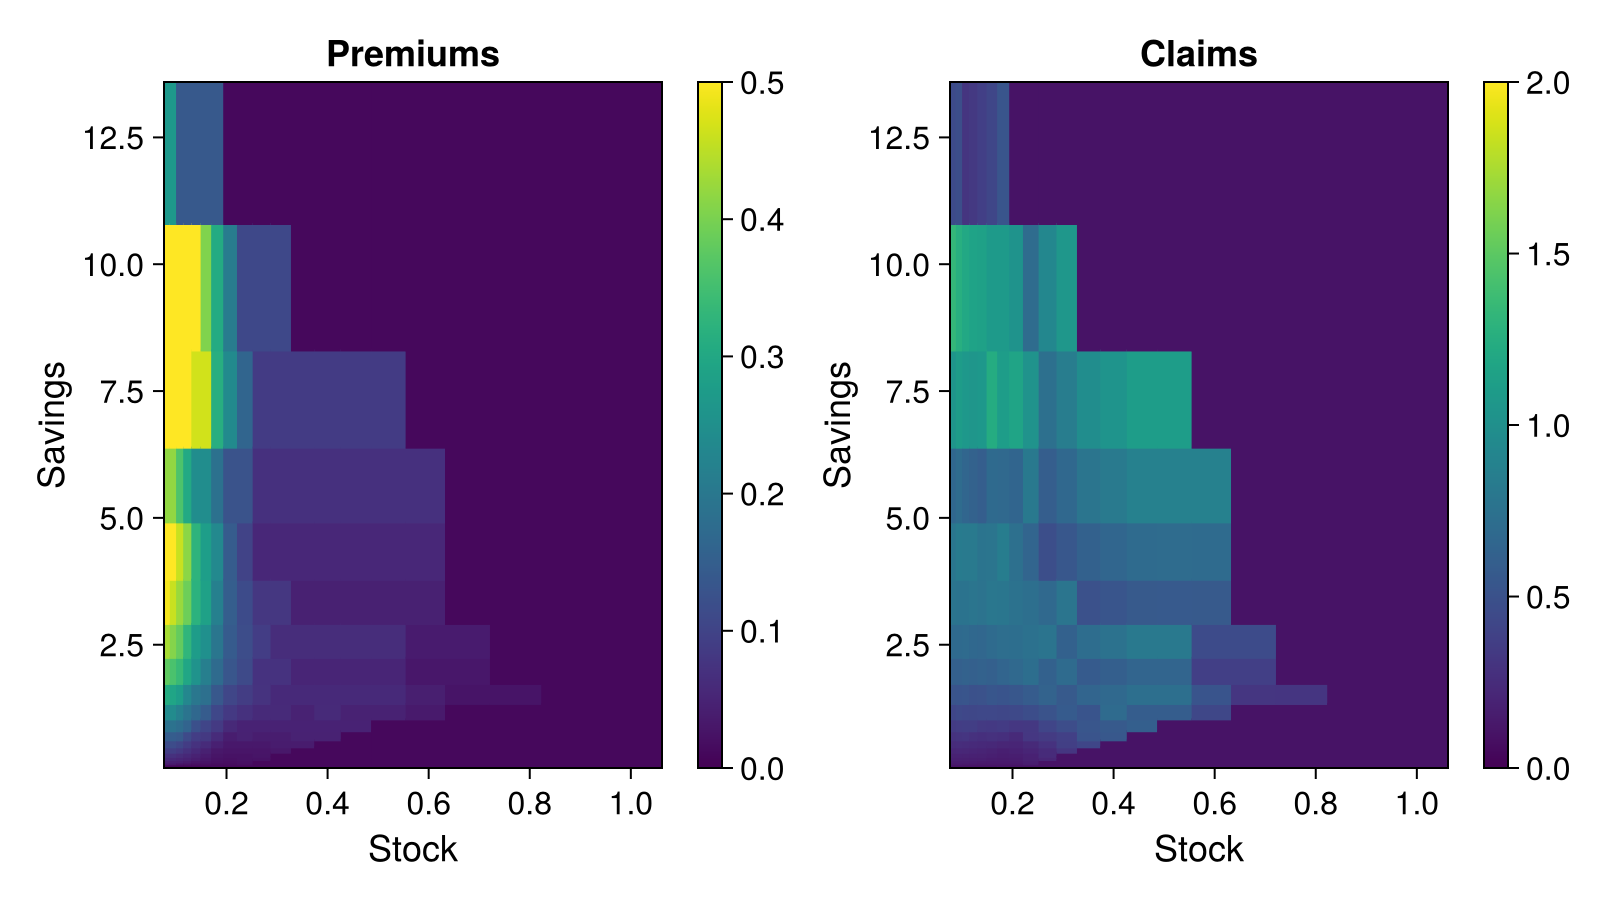

In [23]:
η_1, η̄_1, claims_1, state_1 = coverage_levels("RA_andre_pcod";smax = 2.5)

coverage_1 = η_1./ η̄_1

f = Figure(size = (800,450))
ax1 = CairoMakie.Axis(f[1, 1], title = "Premiums", ylabel = "Savings", xlabel = "Stock", 
        xticklabelsize = 16, titlesize = 18,ylabelsize = 18,xlabelsize = 18,yticklabelsize = 16)

centers_x = collect(exp.(state_1[1]))
centers_y = collect(exp.(state_1[2]))
ind = 2

data1 = η_1[:,:,2,1].+0.01


scale = ReversibleScale(x -> x, x -> x)
hm = CairoMakie.heatmap!(ax1, centers_y,  centers_x, data1';colorscale = scale,colorrange = (0.0,0.5))
CairoMakie.Colorbar(f[1, 2], hm,  ticks = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5], labelsize = 18, ticklabelsize = 16)


ax1 = CairoMakie.Axis(f[1, 3], title = "Claims", xlabel = "Stock", ylabel = "Savings",
        ylabelsize = 18,xlabelsize = 18,xticklabelsize = 16,titlesize = 18,yticklabelsize = 16)
ind = 2

data1 = coverage_1[:,:,ind ,1].*claims_1[:,:,ind ,1].+0.1

hm = CairoMakie.heatmap!(ax1, centers_y,  centers_x, data1';colorscale = scale,colorrange = (0.0,2.0))
CairoMakie.Colorbar(f[1, 4], hm, labelsize = 18, ticklabelsize = 16)
f